In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
fedavg = pd.read_csv("../runs/hfrl_4000.csv")
greedy = pd.read_csv("../runs/greedy_4000.csv")
fedavg.head()

,episode,agent,reward
0,0,v2v_0,5.925540e+09
1,0,v2v_1,5.925540e+09
2,0,v2v_2,5.925540e+09
3,0,v2v_3,5.925540e+09
4,0,v2v_4,5.925540e+09


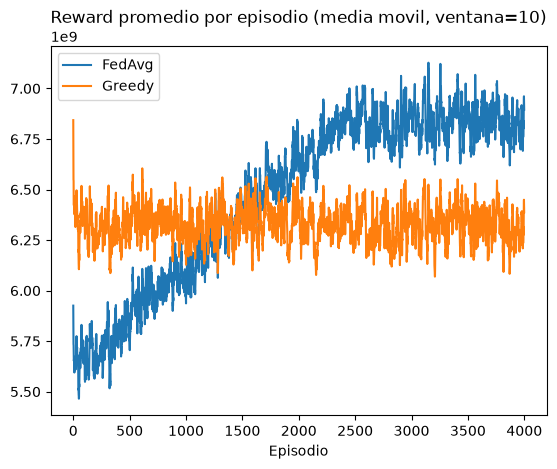

In [17]:
fedavg_reward = fedavg.groupby("episode")["reward"].mean()
greedy_reward = greedy.groupby("episode")["reward"].mean()

window = 10
fedavg_reward.rolling(window, min_periods=1).mean().plot(
    # figsize=(8, 4),
    label="FedAvg"
)
greedy_reward.rolling(window, min_periods=1).mean().plot(label="Greedy")
plt.title(f"Reward promedio por episodio (media movil, ventana={window})")
plt.xlabel("Episodio")
plt.legend()
plt.show()

In [18]:
window = max(1, len(fedavg_reward) // 10)
fedavg_first, fedavg_last = (
    fedavg_reward.iloc[:window].mean(),
    fedavg_reward.iloc[-window:].mean(),
)
fedavg_first, fedavg_last, fedavg_last - fedavg_first

(np.float64(5697361050.106475),
 np.float64(6834666144.589578),
 np.float64(1137305094.4831028))

In [19]:
pd.DataFrame({"FedAvg": fedavg_reward.describe(), "Greedy": greedy_reward.describe()})

,FedAvg,Greedy
count,4.000000e+03,4.000000e+03
mean,6.471069e+09,6.329012e+09
std,4.839590e+08,2.670708e+08
min,5.129135e+09,5.539487e+09
25%,6.119225e+09,6.135814e+09
50%,6.545380e+09,6.309058e+09
75%,6.823997e+09,6.496504e+09
max,8.214516e+09,7.620444e+09
